In [1]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import ot
import pandas as pd
import time
import random
from gwgraphs import *
from scipy.stats import ttest_ind

In [2]:
np.random.seed(42)
random.seed(42)

In [3]:
# Read and Process Graph Data #
def read_graph_data():
    # Read the adjacency matrix (edges)
    with open("COX2_A.txt", "r") as f:
        edges = [tuple(map(int, line.split(','))) for line in f]

    # Read graph indicators
    with open("COX2_graph_indicator.txt", "r") as f:
        graph_indicators = [int(line.strip()) for line in f if line.strip()]

    # Read graph labels
    with open("COX2_graph_labels.txt", "r") as f:
        graph_labels = [int(line.strip()) for line in f]

    # Read node labels
    with open("COX2_node_labels.txt", "r") as f:
        node_labels = [int(line.strip()) for line in f]

    # Read node attributes
    with open("COX2_node_attributes.txt", "r") as f:
        node_attributes = [
            list(map(float,
                     line.strip().split(','))) for line in f if line.strip()
        ]

    return edges, graph_indicators, graph_labels, node_labels, node_attributes


def normalize_features(features):
    features = np.array(features)
    # Normalize each feature dimension independently
    mean = np.mean(features, axis=0)
    std = np.std(features, axis=0)
    # Avoid division by zero
    std[std == 0] = 1
    normalized_features = (features - mean) / std
    return normalized_features.tolist()


def construct_networkx_graph(edges, graph_indicators, graph_labels,
                             node_labels, node_attributes):
    graphs = {}
    graphs_normalized = {}
    
    # Normalize all node attributes
    normalized_attributes = normalize_features(node_attributes)
    
    for node_id, graph_id in enumerate(graph_indicators, start=1):
        if graph_id not in graphs:
            graphs[graph_id] = nx.Graph(label=graph_labels[graph_id - 1])
            graphs_normalized[graph_id] = nx.Graph(label=graph_labels[graph_id - 1])

    for edge in edges:
        node1, node2 = edge
        graph_id = graph_indicators[
            node1 - 1]  # Determine which graph the edge belongs to
        graphs[graph_id].add_edge(node1, node2)
        graphs_normalized[graph_id].add_edge(node1, node2)

    for node_id, (graph_id, node_label,
                  node_attr, norm_attr) in enumerate(zip(graph_indicators, node_labels,
                                              node_attributes, normalized_attributes),
                                          start=1):
        # Original graphs with original features
        graphs[graph_id].nodes[node_id]['label'] = node_label
        graphs[graph_id].nodes[node_id]['attributes'] = node_attr
        
        # Normalized graphs with normalized features
        graphs_normalized[graph_id].nodes[node_id]['label'] = node_label
        graphs_normalized[graph_id].nodes[node_id]['attributes'] = norm_attr

    return graphs, graphs_normalized


def compute_distance_matrix(graph):
    num_nodes = len(graph.nodes)
    distance_matrix = np.full((num_nodes, num_nodes), 10000.0)

    # Get the correct node indices to be used for indexing the matrix
    node_list = list(graph.nodes())
    node_index = {node: i for i, node in enumerate(node_list)}

    for node in graph.nodes:
        lengths = nx.shortest_path_length(graph, source=node, weight="weight")

        for target, length in lengths.items():
            if target in node_index:
                distance_matrix[node_index[node], node_index[target]] = length

    return distance_matrix

In [4]:
edges, graph_indicators, graph_labels, node_labels, node_attributes = read_graph_data(
)
graphs, graphs_normalized = construct_networkx_graph(edges, graph_indicators, graph_labels,
                                                   node_labels, node_attributes)
for graph_id, graph in graphs.items():
    print(
        f"Graph ID: {graph_id}, number of nodes: {graph.number_of_nodes()}, label: {graph.graph['label']}"
    )

Graph ID: 1, number of nodes: 39, label: -1
Graph ID: 2, number of nodes: 36, label: -1
Graph ID: 3, number of nodes: 36, label: 1
Graph ID: 4, number of nodes: 39, label: -1
Graph ID: 5, number of nodes: 42, label: -1
Graph ID: 6, number of nodes: 42, label: -1
Graph ID: 7, number of nodes: 44, label: -1
Graph ID: 8, number of nodes: 39, label: -1
Graph ID: 9, number of nodes: 42, label: 1
Graph ID: 10, number of nodes: 42, label: 1
Graph ID: 11, number of nodes: 45, label: 1
Graph ID: 12, number of nodes: 49, label: 1
Graph ID: 13, number of nodes: 42, label: 1
Graph ID: 14, number of nodes: 35, label: -1
Graph ID: 15, number of nodes: 44, label: 1
Graph ID: 16, number of nodes: 47, label: 1
Graph ID: 17, number of nodes: 45, label: 1
Graph ID: 18, number of nodes: 39, label: 1
Graph ID: 19, number of nodes: 44, label: -1
Graph ID: 20, number of nodes: 44, label: -1
Graph ID: 21, number of nodes: 51, label: -1
Graph ID: 22, number of nodes: 45, label: -1
Graph ID: 23, number of nodes

In [5]:
graphs_list = []
labels_list = []
for graph_id, graph in graphs.items():
    # Add the graph object to the list
    graphs_list.append(graph)

    # Extract the label and add to the label list
    label = graph.graph['label']
    labels_list.append(label)

# Convert graphs into pairwise distance matrices
distance_matrices = [compute_distance_matrix(graph) for graph in graphs_list]

In [6]:
# GW Distances Scatterplots #
# Normalize the matrices
Ms = []
for matrix in distance_matrices:
    Ms.append(matrix / np.max(matrix))
    
N=467
heights = [
    np.full(len(graph), 1 / len(graph)) for graph in graphs_list
]
gw = np.zeros((N,N))

# Track negative values during computation
negative_count = 0
negative_pairs = []

for i in range(N):
    for j in range(i+1,N):
        tmp = ot.gromov.gromov_wasserstein2(Ms[i],Ms[j],heights[i],heights[j],loss_fun="square_loss",log=True)
        gw_value = tmp[0]
        gw[i,j] = gw_value
        
        # Check for negative values
        if gw_value < 0:
            negative_count += 1
            negative_pairs.append((i, j, gw_value))
            print(f"Negative GW distance found: graphs {i} and {j}, value: {gw_value}")
        
        # Check for NaN values
        if np.isnan(gw_value):
            print(f"NaN GW distance found: graphs {i} and {j}")
        
        #Ps_gw[i,j] = tmp[1]["T"]

# Handle negative values by taking absolute value before sqrt
gw_abs = np.abs(gw)
gw = np.sqrt(gw_abs)
gw += gw.T

print(f"\nGW computation summary:")
print(f"Total negative values found: {negative_count}")
print(f"Min GW value: {np.min(gw[gw != 0])}")
print(f"Max GW value: {np.max(gw)}")
print(f"Number of NaN values: {np.sum(np.isnan(gw))}")

# Print first few negative pairs if any
if negative_pairs:
    print(f"\nFirst 5 negative pairs:")
    for i, (idx_i, idx_j, val) in enumerate(negative_pairs[:5]):
        print(f"  Pair {i+1}: graphs {idx_i} and {idx_j}, value: {val}")

Negative GW distance found: graphs 18 and 19, value: -6.418476861114186e-17
Negative GW distance found: graphs 46 and 347, value: -5.377642775528102e-17
Negative GW distance found: graphs 47 and 347, value: -5.377642775528102e-17
Negative GW distance found: graphs 48 and 347, value: -5.377642775528102e-17
Negative GW distance found: graphs 53 and 54, value: -1.491862189340054e-16
Negative GW distance found: graphs 53 and 80, value: -1.491862189340054e-16
Negative GW distance found: graphs 53 and 81, value: -1.491862189340054e-16
Negative GW distance found: graphs 53 and 87, value: -1.491862189340054e-16
Negative GW distance found: graphs 53 and 88, value: -1.491862189340054e-16
Negative GW distance found: graphs 53 and 90, value: -1.491862189340054e-16
Negative GW distance found: graphs 54 and 80, value: -1.491862189340054e-16
Negative GW distance found: graphs 54 and 81, value: -1.491862189340054e-16
Negative GW distance found: graphs 54 and 87, value: -1.491862189340054e-16
Negative 

In [7]:
### WHY NEGATIVE DISTANCES? ###
def check_graph_isomorphism(graph1, graph2):
    """Check if two graphs are isomorphic, considering both structure and node labels."""
    # First check structural isomorphism
    if not nx.is_isomorphic(graph1, graph2):
        return False, "Not structurally isomorphic"
    
    # If structurally isomorphic, check if node labels match
    def node_match(n1, n2):
        return n1.get('label', None) == n2.get('label', None)
    
    if nx.is_isomorphic(graph1, graph2, node_match=node_match):
        return True, "Isomorphic with matching node labels"
    else:
        return True, "Structurally isomorphic but different node labels"

print(f"\n=== ISOMORPHISM ANALYSIS FOR NEGATIVE GW PAIRS ===")
if negative_pairs:
    print(f"Analyzing {len(negative_pairs)} pairs with negative GW distances...\n")
    
    isomorphic_count = 0
    structural_iso_count = 0
    same_label_count = 0
    different_label_count = 0
    
    for idx, (i, j, gw_value) in enumerate(negative_pairs):
        graph1 = graphs_list[i]
        graph2 = graphs_list[j]
        
        is_iso, iso_type = check_graph_isomorphism(graph1, graph2)
        
        # Check if classification labels are the same
        label1 = labels_list[i]
        label2 = labels_list[j]
        same_label = label1 == label2
        
        if same_label:
            same_label_count += 1
            label_status = "Same classification label"
        else:
            different_label_count += 1
            label_status = "Different classification labels"
        
        print(f"Pair {idx+1}: Graphs {i} and {j} (GW distance: {gw_value})")
        print(f"  Nodes: {graph1.number_of_nodes()} vs {graph2.number_of_nodes()}")
        print(f"  Edges: {graph1.number_of_edges()} vs {graph2.number_of_edges()}")
        print(f"  Graph labels: {graph1.graph['label']} vs {graph2.graph['label']}")
        print(f"  Classification labels: {label1} vs {label2} ({label_status})")
        print(f"  Isomorphism: {iso_type}")
        
        if "Isomorphic with matching" in iso_type:
            isomorphic_count += 1
        elif "Structurally isomorphic" in iso_type:
            structural_iso_count += 1
        
        print()
    
    print(f"SUMMARY:")
    print(f"  Total negative pairs: {len(negative_pairs)}")
    print(f"  Pairs with same classification label: {same_label_count}")
    print(f"  Pairs with different classification labels: {different_label_count}")
    print(f"  Fully isomorphic (structure + labels): {isomorphic_count}")
    print(f"  Structurally isomorphic only: {structural_iso_count}")
    print(f"  Not isomorphic: {len(negative_pairs) - isomorphic_count - structural_iso_count}")
else:
    print("No negative GW distances found.")


=== ISOMORPHISM ANALYSIS FOR NEGATIVE GW PAIRS ===
Analyzing 128 pairs with negative GW distances...

Pair 1: Graphs 18 and 19 (GW distance: -6.418476861114186e-17)
  Nodes: 44 vs 44
  Edges: 46 vs 46
  Graph labels: -1 vs -1
  Classification labels: -1 vs -1 (Same classification label)
  Isomorphism: Structurally isomorphic but different node labels

Pair 2: Graphs 46 and 347 (GW distance: -5.377642775528102e-17)
  Nodes: 37 vs 37
  Edges: 39 vs 39
  Graph labels: -1 vs -1
  Classification labels: -1 vs -1 (Same classification label)
  Isomorphism: Structurally isomorphic but different node labels

Pair 3: Graphs 47 and 347 (GW distance: -5.377642775528102e-17)
  Nodes: 37 vs 37
  Edges: 39 vs 39
  Graph labels: -1 vs -1
  Classification labels: -1 vs -1 (Same classification label)
  Isomorphism: Structurally isomorphic but different node labels

Pair 4: Graphs 48 and 347 (GW distance: -5.377642775528102e-17)
  Nodes: 37 vs 37
  Edges: 39 vs 39
  Graph labels: -1 vs -1
  Classificati

In [8]:
### Compare all graphs in dataset to determine which are isomorphic ###
# Check for isomorphic graphs
isomorphic_pairs = []
same_label_count = 0
neg_one_pairs = 0
pos_one_pairs = 0

for i in range(N):
    for j in range(i + 1, N):
        if check_graph_isomorphism(graphs_list[i], graphs_list[j])[0]:
            isomorphic_pairs.append((i, j))
            print(f"Graphs {i} and {j} are isomorphic.")
            print(
                f"  Graph {i} has {graphs_list[i].number_of_nodes()} nodes and {graphs_list[i].number_of_edges()} edges."
            )
            print(
                f"  Graph {j} has {graphs_list[j].number_of_nodes()} nodes and {graphs_list[j].number_of_edges()} edges."
            )
            print(
                f"  Classification labels: {labels_list[i]} vs {labels_list[j]}"
            )
            tmp = ot.gromov.gromov_wasserstein2(Ms[i],Ms[j],heights[i],heights[j],loss_fun="square_loss",log=True)
            print(f"  GW Distance between Graph {i} and Graph {j}: {np.sqrt(np.abs(tmp[0]))}")
            if labels_list[i] == labels_list[j]:
                same_label_count += 1
                print("Same classification label.")
            if labels_list[i] == 1 and labels_list[j] == 1:
                pos_one_pairs += 1
                print("Both graphs have label 1.")
            if labels_list[i] == -1 and labels_list[j] == -1:
                neg_one_pairs += 1
                print("Both graphs have label -1.")
            print()

print(f"Total number of graph pairs: {N * (N - 1) / 2}")
print(f"Total isomorphic pairs found: {len(isomorphic_pairs)}")
print(f"Pairs with same classification label: {same_label_count}")
print(f"Pairs with both graphs having label 1: {pos_one_pairs}")
print(f"Pairs with both graphs having label -1: {neg_one_pairs}")

Graphs 0 and 3 are isomorphic.
  Graph 0 has 39 nodes and 41 edges.
  Graph 3 has 39 nodes and 41 edges.
  Classification labels: -1 vs -1
  GW Distance between Graph 0 and Graph 3: 0.019325362862192042
Same classification label.
Both graphs have label -1.

Graphs 0 and 7 are isomorphic.
  Graph 0 has 39 nodes and 41 edges.
  Graph 7 has 39 nodes and 41 edges.
  Classification labels: -1 vs -1
  GW Distance between Graph 0 and Graph 7: 0.019325362862192042
Same classification label.
Both graphs have label -1.

Graphs 0 and 17 are isomorphic.
  Graph 0 has 39 nodes and 41 edges.
  Graph 17 has 39 nodes and 41 edges.
  Classification labels: -1 vs 1
  GW Distance between Graph 0 and Graph 17: 0.022315006901348463

Graphs 0 and 24 are isomorphic.
  Graph 0 has 39 nodes and 41 edges.
  Graph 24 has 39 nodes and 41 edges.
  Classification labels: -1 vs -1
  GW Distance between Graph 0 and Graph 24: 0.022315006901348463
Same classification label.
Both graphs have label -1.

Graphs 0 and 25 a

Within Active class - Mean: 0.0995, Std: 0.0305
Within Inactive class - Mean: 0.0891, Std: 0.0287
Between classes - Mean: 0.0949, Std: 0.0293


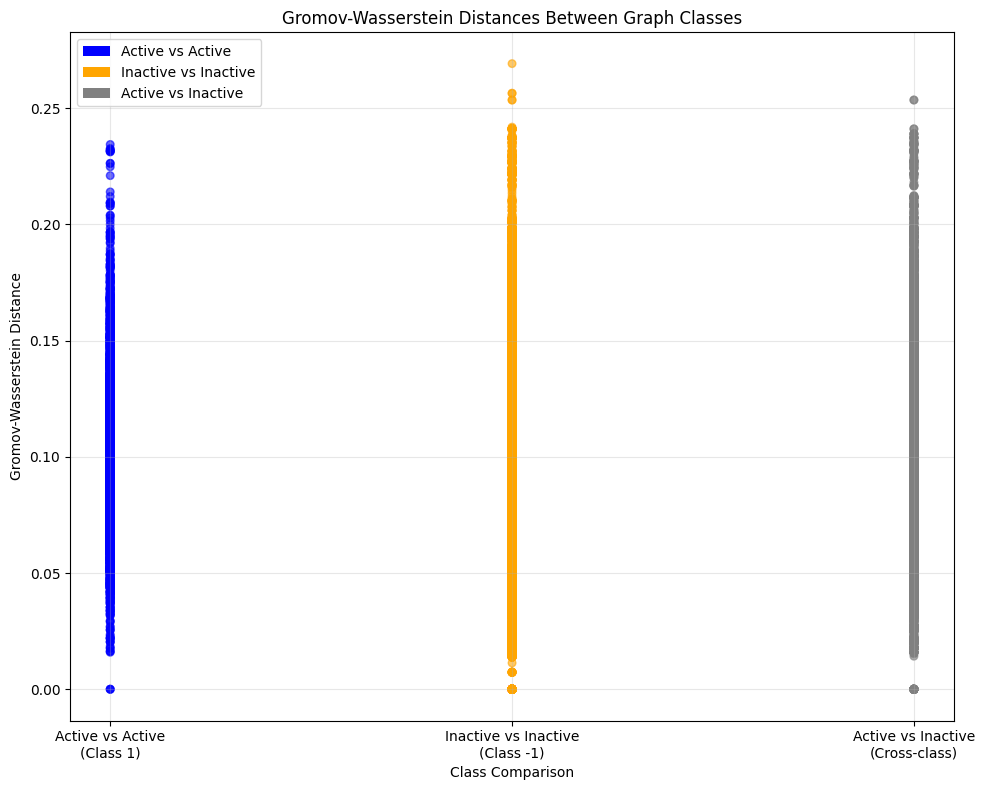

In [9]:
# Create scatterplot of GW distances by class
plt.figure(figsize=(10, 8))

# Convert labels to numpy array for easier indexing
labels_array = np.array(labels_list)

# Get indices for each class
class_1_indices = np.where(labels_array == 1)[0]  # Active class
class_minus1_indices = np.where(labels_array == -1)[0]  # Inactive class

# Extract GW distances for different class combinations
# Within class 1 (active vs active)
within_class1_distances = []
for i in range(len(class_1_indices)):
    for j in range(i+1, len(class_1_indices)):
        idx_i, idx_j = class_1_indices[i], class_1_indices[j]
        within_class1_distances.append(gw[idx_i, idx_j])

# Within class -1 (inactive vs inactive)
within_class_minus1_distances = []
for i in range(len(class_minus1_indices)):
    for j in range(i+1, len(class_minus1_indices)):
        idx_i, idx_j = class_minus1_indices[i], class_minus1_indices[j]
        within_class_minus1_distances.append(gw[idx_i, idx_j])

# Between classes (active vs inactive)
between_classes_distances = []
for i in class_1_indices:
    for j in class_minus1_indices:
        between_classes_distances.append(gw[i, j])

# Create scatter plot
x_positions = []
distances = []
colors = []
labels_plot = []

# Add within class 1 distances
x_positions.extend([0] * len(within_class1_distances))
distances.extend(within_class1_distances)
colors.extend(['blue'] * len(within_class1_distances))
labels_plot.extend(['Active vs Active'] * len(within_class1_distances))

# Add within class -1 distances
x_positions.extend([1] * len(within_class_minus1_distances))
distances.extend(within_class_minus1_distances)
colors.extend(['orange'] * len(within_class_minus1_distances))
labels_plot.extend(['Inactive vs Inactive'] * len(within_class_minus1_distances))

# Add between classes distances
x_positions.extend([2] * len(between_classes_distances))
distances.extend(between_classes_distances)
colors.extend(['gray'] * len(between_classes_distances))
labels_plot.extend(['Active vs Inactive'] * len(between_classes_distances))

# Create the scatter plot
scatter = plt.scatter(x_positions, distances, c=colors, alpha=0.6, s=30)
# Customize the plot
plt.xlabel('Class Comparison')
plt.ylabel('Gromov-Wasserstein Distance')
plt.title('Gromov-Wasserstein Distances Between Graph Classes')
plt.xticks([0, 1, 2], ['Active vs Active\n(Class 1)', 'Inactive vs Inactive\n(Class -1)', 'Active vs Inactive\n(Cross-class)'])
legend_elements = [Patch(facecolor='blue', label='Active vs Active'),
                   Patch(facecolor='orange', label='Inactive vs Inactive'),
                   Patch(facecolor='gray', label='Active vs Inactive')]
plt.legend(handles=legend_elements)

# Add some statistics
print(f"Within Active class - Mean: {np.mean(within_class1_distances):.4f}, Std: {np.std(within_class1_distances):.4f}")
print(f"Within Inactive class - Mean: {np.mean(within_class_minus1_distances):.4f}, Std: {np.std(within_class_minus1_distances):.4f}")
print(f"Between classes - Mean: {np.mean(between_classes_distances):.4f}, Std: {np.std(between_classes_distances):.4f}")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [10]:
# Perform statistical test
active_vs_inactive_mean = np.mean(between_classes_distances)
within_active_mean = np.mean(within_class1_distances)
within_inactive_mean = np.mean(within_class_minus1_distances)

print(f"\nStatistical Summary:")
print(f"Number of Active graphs: {len(class_1_indices)}")
print(f"Number of Inactive graphs: {len(class_minus1_indices)}")
print(f"Number of within-Active comparisons: {len(within_class1_distances)}")
print(f"Number of within-Inactive comparisons: {len(within_class_minus1_distances)}")
print(f"Number of cross-class comparisons: {len(between_classes_distances)}")

# Test if between-class distances are significantly different from within-class distances
all_within_class = within_class1_distances + within_class_minus1_distances
t_stat, p_value = ttest_ind(between_classes_distances, all_within_class)
print(f"\nT-test (Between-class vs Within-class distances):")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"Significant difference: {'Yes' if p_value < 0.05 else 'No'}")


Statistical Summary:
Number of Active graphs: 102
Number of Inactive graphs: 365
Number of within-Active comparisons: 5151
Number of within-Inactive comparisons: 66430
Number of cross-class comparisons: 37230

T-test (Between-class vs Within-class distances):
T-statistic: 27.4023
P-value: 0.0000
Significant difference: Yes


In [11]:
# gLGW Distances Scatterplots #

In [12]:
k_bary = 41  # use average
idx_bary = []
classes = [-1,1]

for i in classes:
    # Find the indices of instances with label i
    labels_list = np.asarray(labels_list) 
    indices = np.where(labels_list == i)[0]
    if indices.size > 0:
        idx_bary.extend(np.random.choice(indices, size=min(5, len(indices)), replace=False))

# Initialize reference matrix with k_bary size
M_ref = np.zeros((k_bary, k_bary))
selected_Ms = [Ms[i] for i in idx_bary]
selected_heights = [heights[i] for i in idx_bary]
lambdas = ot.unif(len(idx_bary))

M_ref = ot.gromov.gromov_barycenters(k_bary,
                                     Cs=selected_Ms,
                                     ps=selected_heights,
                                     p=ot.unif(k_bary),
                                     lambdas=lambdas,
                                     loss_fun='square_loss',
                                     max_iter=200,
                                     tol=1e-12,
                                     random_state=42)

height_ref = ot.unif(k_bary)
lgw_matrix, lgw_time = lgw_procedure(M_ref,
                                     height_ref,
                                     None,
                                     Ms,
                                     heights,
                                     mode="graph")

In [13]:
print(f"\ngLGW computation summary:")
print(f"gLGW computation time: {lgw_time:.4f} seconds")
print(f"Min gLGW value: {np.min(lgw_matrix[lgw_matrix != 0])}")
print(f"Max gLGW value: {np.max(lgw_matrix)}")
print(f"Number of NaN values: {np.sum(np.isnan(lgw_matrix))}")

negative_lgw_count = np.sum(lgw_matrix < 0)
if negative_lgw_count > 0:
    print(f"Warning: {negative_lgw_count} negative gLGW values found!")


gLGW computation summary:
gLGW computation time: 3.1673 seconds
Min gLGW value: 0.014543531560974241
Max gLGW value: 0.2606030229397205
Number of NaN values: 0



gLGW Distance Statistics:
Within Active class - Mean: 0.1256, Std: 0.0366
Within Inactive class - Mean: 0.1136, Std: 0.0346
Between classes - Mean: 0.1200, Std: 0.0353


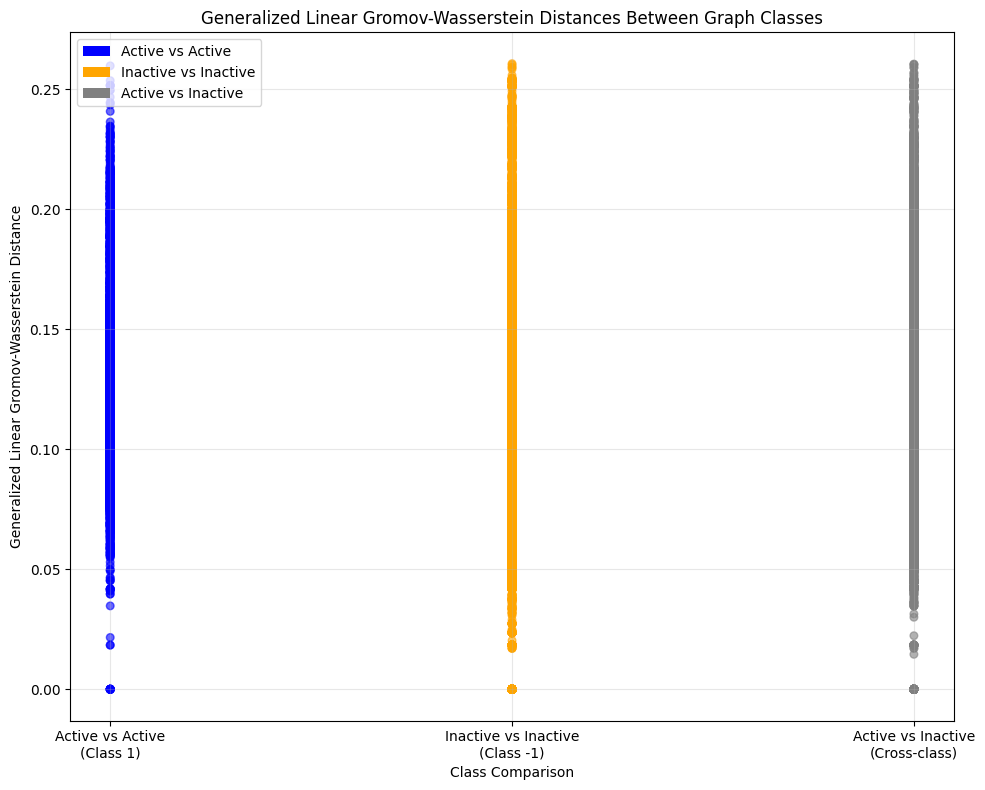

In [14]:
# Create scatterplot of gLGW distances by class
plt.figure(figsize=(10, 8))

# Convert labels to numpy array for easier indexing
labels_array = np.array(labels_list)

# Get indices for each class
class_1_indices = np.where(labels_array == 1)[0]  # Active class
class_minus1_indices = np.where(labels_array == -1)[0]  # Inactive class

# Extract gLGW distances for different class combinations
# Within class 1 (active vs active)
within_class1_lgw_distances = []
for i in range(len(class_1_indices)):
    for j in range(i+1, len(class_1_indices)):
        idx_i, idx_j = class_1_indices[i], class_1_indices[j]
        within_class1_lgw_distances.append(lgw_matrix[idx_i, idx_j])

# Within class -1 (inactive vs inactive)
within_class_minus1_lgw_distances = []
for i in range(len(class_minus1_indices)):
    for j in range(i+1, len(class_minus1_indices)):
        idx_i, idx_j = class_minus1_indices[i], class_minus1_indices[j]
        within_class_minus1_lgw_distances.append(lgw_matrix[idx_i, idx_j])

# Between classes (active vs inactive)
between_classes_lgw_distances = []
for i in class_1_indices:
    for j in class_minus1_indices:
        between_classes_lgw_distances.append(lgw_matrix[i, j])

# Create scatter plot
x_positions_lgw = []
distances_lgw = []
colors_lgw = []
labels_plot_lgw = []

# Add within class 1 distances
x_positions_lgw.extend([0] * len(within_class1_lgw_distances))
distances_lgw.extend(within_class1_lgw_distances)
colors_lgw.extend(['blue'] * len(within_class1_lgw_distances))
labels_plot_lgw.extend(['Active vs Active'] * len(within_class1_lgw_distances))

# Add within class -1 distances
x_positions_lgw.extend([1] * len(within_class_minus1_lgw_distances))
distances_lgw.extend(within_class_minus1_lgw_distances)
colors_lgw.extend(['orange'] * len(within_class_minus1_lgw_distances))
labels_plot_lgw.extend(['Inactive vs Inactive'] * len(within_class_minus1_lgw_distances))

# Add between classes distances
x_positions_lgw.extend([2] * len(between_classes_lgw_distances))
distances_lgw.extend(between_classes_lgw_distances)
colors_lgw.extend(['gray'] * len(between_classes_lgw_distances))
labels_plot_lgw.extend(['Active vs Inactive'] * len(between_classes_lgw_distances))

# Create the scatter plot
scatter_lgw = plt.scatter(x_positions_lgw, distances_lgw, c=colors_lgw, alpha=0.6, s=30)

# Customize the plot
plt.xlabel('Class Comparison')
plt.ylabel('Generalized Linear Gromov-Wasserstein Distance')
plt.title('Generalized Linear Gromov-Wasserstein Distances Between Graph Classes')
plt.xticks([0, 1, 2], ['Active vs Active\n(Class 1)', 'Inactive vs Inactive\n(Class -1)', 'Active vs Inactive\n(Cross-class)'])

# Add legend
from matplotlib.patches import Patch
legend_elements_lgw = [Patch(facecolor='blue', label='Active vs Active'),
                       Patch(facecolor='orange', label='Inactive vs Inactive'),
                       Patch(facecolor='gray', label='Active vs Inactive')]
plt.legend(handles=legend_elements_lgw)

# Add some statistics
print(f"\ngLGW Distance Statistics:")
print(f"Within Active class - Mean: {np.mean(within_class1_lgw_distances):.4f}, Std: {np.std(within_class1_lgw_distances):.4f}")
print(f"Within Inactive class - Mean: {np.mean(within_class_minus1_lgw_distances):.4f}, Std: {np.std(within_class_minus1_lgw_distances):.4f}")
print(f"Between classes - Mean: {np.mean(between_classes_lgw_distances):.4f}, Std: {np.std(between_classes_lgw_distances):.4f}")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
# Perform statistical test for gLGW
active_vs_inactive_lgw_mean = np.mean(between_classes_lgw_distances)
within_active_lgw_mean = np.mean(within_class1_lgw_distances)
within_inactive_lgw_mean = np.mean(within_class_minus1_lgw_distances)

print(f"\ngLGW Statistical Summary:")
print(f"Number of Active graphs: {len(class_1_indices)}")
print(f"Number of Inactive graphs: {len(class_minus1_indices)}")
print(f"Number of within-Active comparisons: {len(within_class1_lgw_distances)}")
print(f"Number of within-Inactive comparisons: {len(within_class_minus1_lgw_distances)}")
print(f"Number of cross-class comparisons: {len(between_classes_lgw_distances)}")

# Test if between-class gLGW distances are significantly different from within-class distances
all_within_class_lgw = within_class1_lgw_distances + within_class_minus1_lgw_distances
t_stat_lgw, p_value_lgw = ttest_ind(between_classes_lgw_distances, all_within_class_lgw)
print(f"\nT-test for LGW (Between-class vs Within-class distances):")
print(f"T-statistic: {t_stat_lgw:.4f}")
print(f"P-value: {p_value_lgw:.4f}")
print(f"Significant difference: {'Yes' if p_value_lgw < 0.05 else 'No'}")

# Additional comparison between GW and LGW results
print(f"gLGW between-class mean: {active_vs_inactive_lgw_mean:.4f}")
print(f"gLGW within-active mean: {within_active_lgw_mean:.4f}")
print(f"gLGW within-inactive mean: {within_inactive_lgw_mean:.4f}")


gLGW Statistical Summary:
Number of Active graphs: 102
Number of Inactive graphs: 365
Number of within-Active comparisons: 5151
Number of within-Inactive comparisons: 66430
Number of cross-class comparisons: 37230

T-test for LGW (Between-class vs Within-class distances):
T-statistic: 24.9560
P-value: 0.0000
Significant difference: Yes
gLGW between-class mean: 0.1200
gLGW within-active mean: 0.1256
gLGW within-inactive mean: 0.1136


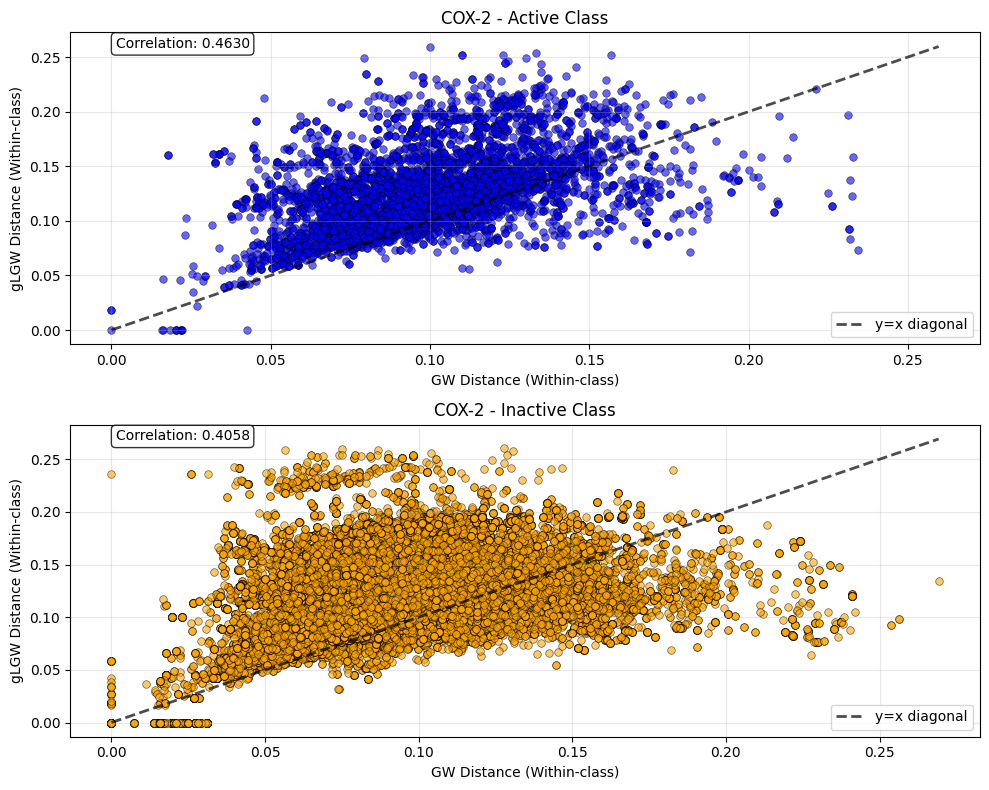

In [16]:
## 2D GW vs. gLGW comparison ##
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))
labels_array = np.array(labels_list)

def create_within_class_gw_vs_lgw_scatterplot(gw_matrix, lgw_matrix, labels_array, ax, title, class_label):
    """Create a 2D scatterplot comparing within-class GW vs gLGW distances for a specific class"""

    # Get indices for the specific class
    if class_label == 1:
        class_indices = np.where(labels_array == 1)[0]  # ER class
        class_name = "Active"
        color = 'blue'
    else:
        class_indices = np.where(labels_array == -1)[0]  # SBM class
        class_name = "Inactive"
        color = 'orange'

    # Extract within-class distances only
    gw_within_class = []
    lgw_within_class = []

    for i in range(len(class_indices)):
        for j in range(i + 1, len(class_indices)):
            idx_i, idx_j = class_indices[i], class_indices[j]
            gw_within_class.append(gw_matrix[idx_i, idx_j])
            lgw_within_class.append(lgw_matrix[idx_i, idx_j])

    # Create scatter plot
    ax.scatter(gw_within_class, lgw_within_class, alpha=0.6, s=30, color=color, 
               edgecolors='black', linewidth=0.5)

    # Add diagonal line for comparison
    if len(gw_within_class) > 0:
        min_val = min(min(gw_within_class), min(lgw_within_class))
        max_val = max(max(gw_within_class), max(lgw_within_class))
        ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.7, linewidth=2, label='y=x diagonal')

    # Customize the plot
    ax.set_xlabel('GW Distance (Within-class)')
    ax.set_ylabel('gLGW Distance (Within-class)')
    ax.set_title(f'{title} - {class_name} Class')
    ax.grid(True, alpha=0.3)
    ax.legend()

    # Calculate correlation coefficient if there are enough points
    if len(gw_within_class) > 1:
        correlation = np.corrcoef(gw_within_class, lgw_within_class)[0, 1]
        ax.text(0.05, 0.95, f'Correlation: {correlation:.4f}', transform=ax.transAxes, 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    else:
        correlation = np.nan
        ax.text(0.05, 0.95, 'Insufficient data', transform=ax.transAxes, 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    return gw_within_class, lgw_within_class, correlation

# Create scatterplots for both datasets and both classes
gw_within_active_1, lgw_within_active_1, corr_active_1 = create_within_class_gw_vs_lgw_scatterplot(
    gw, lgw_matrix, labels_array, ax1, 'COX-2', 1
)

gw_within_inactive_1, lgw_within_inactive_1, corr_inactive_1 = create_within_class_gw_vs_lgw_scatterplot(
    gw, lgw_matrix, labels_array, ax2, 'COX-2', -1
)
plt.tight_layout()

In [17]:
# fGW Distances Scatterplots #

# Initialize fGW distance matrix
fgw_matrix = np.zeros((N, N))

# Track negative values during computation
negative_fgw_count = 0
negative_fgw_pairs = []

# Compute fused Gromov-Wasserstein distances
for i in range(N):
    for j in range(i + 1, N):
        # Get features for both graphs
        graph_i = graphs_list[i]
        graph_j = graphs_list[j]

        # Extract node features
        features_i = np.array(
            [graph_i.nodes[n]['attributes'] for n in graph_i.nodes()])
        features_j = np.array(
            [graph_j.nodes[n]['attributes'] for n in graph_j.nodes()])

        # Compute metric cost matrix between features
        M = ot.dist(features_i, features_j, metric='euclidean')

        # Compute fGW distance
        try:
            fgw_result = ot.gromov.fused_gromov_wasserstein2(
                M,
                Ms[i],
                Ms[j],
                heights[i],
                heights[j],
                loss_fun='square_loss',
                alpha=0.0,
                log=True)
            fgw_value = fgw_result[0]
            fgw_matrix[i, j] = fgw_value

            # Check for negative values
            if fgw_value < 0:
                negative_fgw_count += 1
                negative_fgw_pairs.append((i, j, fgw_value))

            # Check for NaN values
            if np.isnan(fgw_value):
                print(f"NaN fGW distance found: graphs {i} and {j}")

        except Exception as e:
            print(
                f"Error computing fGW distance between graphs {i} and {j}: {e}"
            )
            fgw_matrix[i, j] = np.nan

# Make matrix symmetric
fgw_matrix += fgw_matrix.T

print(f"\nfGW computation summary:")
print(f"Total negative values found: {negative_fgw_count}")
print(f"Min fGW value: {np.min(fgw_matrix[fgw_matrix != 0])}")
print(f"Max fGW value: {np.max(fgw_matrix)}")
print(f"Number of NaN values: {np.sum(np.isnan(fgw_matrix))}")

# Print first few negative pairs if any
if negative_fgw_pairs:
    print(f"\nFirst 5 negative fGW pairs:")
    for i, (idx_i, idx_j, val) in enumerate(negative_fgw_pairs[:5]):
        print(f"  Pair {i+1}: graphs {idx_i} and {idx_j}, value: {val}")

# Handle negative values by taking absolute value if needed
if negative_fgw_count > 0:
    print("Taking absolute values of negative fGW distances...")
    fgw_matrix = np.abs(fgw_matrix)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/ot/gromov/_gw.py:623: RuntimeWarning: divide by zero encountered in scalar divide
  gw_term = log_fgw['quad_loss'] / alpha
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/ot/gromov/_gw.py:623: RuntimeWarning: invalid value encountered in scalar divide
  gw_term = log_fgw['quad_loss'] / alpha



fGW computation summary:
Total negative values found: 0
Min fGW value: 0.002576707835121539
Max fGW value: 3.656493407960493
Number of NaN values: 0



fGW Distance Statistics:
Within Active class - Mean: 1.2551, Std: 0.4664
Within Inactive class - Mean: 1.1704, Std: 0.4444
Between classes - Mean: 1.2231, Std: 0.4484


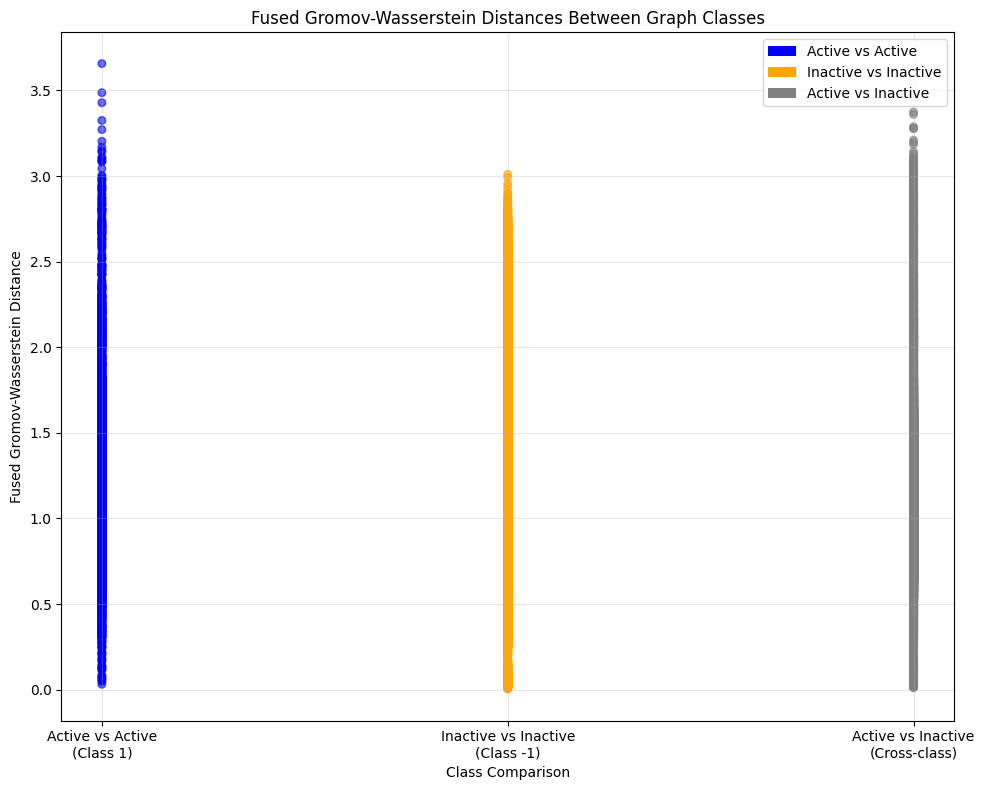

In [18]:
# Create scatterplot of fGW distances by class
plt.figure(figsize=(10, 8))

# Convert labels to numpy array for easier indexing
labels_array = np.array(labels_list)

# Get indices for each class
class_1_indices = np.where(labels_array == 1)[0]  # Active class
class_minus1_indices = np.where(labels_array == -1)[0]  # Inactive class

# Extract fGW distances for different class combinations
# Within class 1 (active vs active)
within_class1_fgw_distances = []
for i in range(len(class_1_indices)):
    for j in range(i + 1, len(class_1_indices)):
        idx_i, idx_j = class_1_indices[i], class_1_indices[j]
        within_class1_fgw_distances.append(fgw_matrix[idx_i, idx_j])

# Within class -1 (inactive vs inactive)
within_class_minus1_fgw_distances = []
for i in range(len(class_minus1_indices)):
    for j in range(i + 1, len(class_minus1_indices)):
        idx_i, idx_j = class_minus1_indices[i], class_minus1_indices[j]
        within_class_minus1_fgw_distances.append(fgw_matrix[idx_i, idx_j])

# Between classes (active vs inactive)
between_classes_fgw_distances = []
for i in class_1_indices:
    for j in class_minus1_indices:
        between_classes_fgw_distances.append(fgw_matrix[i, j])

# Create scatter plot
x_positions_fgw = []
distances_fgw = []
colors_fgw = []
labels_plot_fgw = []

# Add within class 1 distances
x_positions_fgw.extend([0] * len(within_class1_fgw_distances))
distances_fgw.extend(within_class1_fgw_distances)
colors_fgw.extend(['blue'] * len(within_class1_fgw_distances))
labels_plot_fgw.extend(['Active vs Active'] * len(within_class1_fgw_distances))

# Add within class -1 distances
x_positions_fgw.extend([1] * len(within_class_minus1_fgw_distances))
distances_fgw.extend(within_class_minus1_fgw_distances)
colors_fgw.extend(['orange'] * len(within_class_minus1_fgw_distances))
labels_plot_fgw.extend(['Inactive vs Inactive'] *
                       len(within_class_minus1_fgw_distances))

# Add between classes distances
x_positions_fgw.extend([2] * len(between_classes_fgw_distances))
distances_fgw.extend(between_classes_fgw_distances)
colors_fgw.extend(['gray'] * len(between_classes_fgw_distances))
labels_plot_fgw.extend(['Active vs Inactive'] *
                       len(between_classes_fgw_distances))

# Create the scatter plot
scatter_fgw = plt.scatter(x_positions_fgw,
                          distances_fgw,
                          c=colors_fgw,
                          alpha=0.6,
                          s=30)

# Customize the plot
plt.xlabel('Class Comparison')
plt.ylabel('Fused Gromov-Wasserstein Distance')
plt.title('Fused Gromov-Wasserstein Distances Between Graph Classes')
plt.xticks([0, 1, 2], [
    'Active vs Active\n(Class 1)', 'Inactive vs Inactive\n(Class -1)',
    'Active vs Inactive\n(Cross-class)'
])

# Add legend
legend_elements_fgw = [
    Patch(facecolor='blue', label='Active vs Active'),
    Patch(facecolor='orange', label='Inactive vs Inactive'),
    Patch(facecolor='gray', label='Active vs Inactive')
]
plt.legend(handles=legend_elements_fgw)

# Add some statistics
print(f"\nfGW Distance Statistics:")
print(
    f"Within Active class - Mean: {np.mean(within_class1_fgw_distances):.4f}, Std: {np.std(within_class1_fgw_distances):.4f}"
)
print(
    f"Within Inactive class - Mean: {np.mean(within_class_minus1_fgw_distances):.4f}, Std: {np.std(within_class_minus1_fgw_distances):.4f}"
)
print(
    f"Between classes - Mean: {np.mean(between_classes_fgw_distances):.4f}, Std: {np.std(between_classes_fgw_distances):.4f}"
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
# Perform statistical test for fGW
active_vs_inactive_fgw_mean = np.mean(between_classes_fgw_distances)
within_active_fgw_mean = np.mean(within_class1_fgw_distances)
within_inactive_fgw_mean = np.mean(within_class_minus1_fgw_distances)

print(f"\nfGW Statistical Summary:")
print(f"Number of Active graphs: {len(class_1_indices)}")
print(f"Number of Inactive graphs: {len(class_minus1_indices)}")
print(
    f"Number of within-Active comparisons: {len(within_class1_fgw_distances)}")
print(
    f"Number of within-Inactive comparisons: {len(within_class_minus1_fgw_distances)}"
)
print(
    f"Number of cross-class comparisons: {len(between_classes_fgw_distances)}")

# Test if between-class fGW distances are significantly different from within-class distances
all_within_class_fgw = within_class1_fgw_distances + within_class_minus1_fgw_distances
t_stat_fgw, p_value_fgw = ttest_ind(between_classes_fgw_distances,
                                    all_within_class_fgw)
print(f"\nT-test for fGW (Between-class vs Within-class distances):")
print(f"T-statistic: {t_stat_fgw:.4f}")
print(f"P-value: {p_value_fgw:.4f}")
print(f"Significant difference: {'Yes' if p_value_fgw < 0.05 else 'No'}")

# Final comparison between all three methods
print(f"fGW between-class mean: {active_vs_inactive_fgw_mean:.4f}")
print(f"fGW within-active mean: {within_active_fgw_mean:.4f}")
print(f"fGW within-inactive mean: {within_inactive_fgw_mean:.4f}")


fGW Statistical Summary:
Number of Active graphs: 102
Number of Inactive graphs: 365
Number of within-Active comparisons: 5151
Number of within-Inactive comparisons: 66430
Number of cross-class comparisons: 37230

T-test for fGW (Between-class vs Within-class distances):
T-statistic: 16.3064
P-value: 0.0000
Significant difference: Yes
fGW between-class mean: 1.2231
fGW within-active mean: 1.2551
fGW within-inactive mean: 1.1704


In [20]:
### Distances Scatterplots: Distances from GW & fGW Barycenters of Each Class ###
# Compute the GW barycenter for each category
num_nodes = 41
seed = 42
X_class1 = [
           distance_matrices[j] for j in range(len(distance_matrices)) if labels_list[j] == -1
        ]
X_class2 = [
            distance_matrices[j] for j in range(len(distance_matrices)) if labels_list[j] == 1
        ]

In [21]:
barycenter_matrix_class1 = ot.gromov.gromov_barycenters(
    N=num_nodes,
    Cs=X_class1,
    loss_fun='square_loss',
    random_state=seed)
print("GW barycenter for Class 1 graphs:",
          barycenter_matrix_class1)
print("GW barycenter for Class 1 graphs computed")
barycenter_matrix_class2 = ot.gromov.gromov_barycenters(
    N=num_nodes,
    Cs=X_class2,
    loss_fun='square_loss',
    random_state=seed)
print("GW barycenter for Class 2 graphs:",
          barycenter_matrix_class2)
print("GW barycenter for Class 2 graphs computed")

GW barycenter for Class 1 graphs: [[ 0.26453731  5.5528365   1.83905901 ...  4.29140673  8.11741931
   1.71896325]
 [ 5.5528365   0.1397666   7.1702114  ...  9.62436765 13.4332655
   4.9943477 ]
 [ 1.83905901  7.1702114   0.28079804 ...  2.60150324  6.49247499
   2.30555584]
 ...
 [ 4.29140673  9.62436765  2.60150324 ...  0.49238476  5.18601715
   4.75379557]
 [ 8.11741931 13.4332655   6.49247499 ...  5.18601715  0.24771805
   8.56966238]
 [ 1.71896325  4.9943477   2.30555584 ...  4.75379557  8.56966238
   0.39965236]]
GW barycenter for Class 1 graphs computed
GW barycenter for Class 2 graphs: [[ 0.54608108  7.30011072  1.65586806 ...  2.02887102  7.66335137
   2.70931272]
 [ 7.30011072  0.22930463  6.39489597 ...  7.34838726 12.81785127
   4.82339355]
 [ 1.65586806  6.39489597  0.27302201 ...  1.06402705  6.55843157
   1.68042371]
 ...
 [ 2.02887102  7.34838726  1.06402705 ...  0.28798333  5.72272243
   2.61913393]
 [ 7.66335137 12.81785127  6.55843157 ...  5.72272243  0.24473273
   8

In [22]:
def compute_gromov_wasserstein_distance(adj_matrix1, adj_matrix2):
    """
    Compute the Gromov-Wasserstein distance between two adjacency matrices.
    
    Args:
        adj_matrix1: First adjacency matrix
        adj_matrix2: Second adjacency matrix
    
    Returns:
        The Gromov-Wasserstein distance
    """
    n1, n2 = adj_matrix1.shape[0], adj_matrix2.shape[0]
    
    # Create uniform distributions
    p = np.ones(n1) / n1
    q = np.ones(n2) / n2
    
    # Compute Gromov-Wasserstein distance
    gw_dist = np.abs(ot.gromov.gromov_wasserstein2(adj_matrix1, adj_matrix2, p, q, 'square_loss'))
    
    return np.sqrt(gw_dist)

In [23]:
# Distances from each class to each barycenter
gw_distances_from_negone_to_negonebary = []
gw_distances_from_one_to_negonebary = []
gw_distances_from_negone_to_onebary = []
gw_distances_from_one_to_onebary = []

for j in range(len(distance_matrices)):
    if labels_list[j] == -1:
        dist_negone = compute_gromov_wasserstein_distance(distance_matrices[j], barycenter_matrix_class1)
        dist_one = compute_gromov_wasserstein_distance(distance_matrices[j], barycenter_matrix_class2)
        gw_distances_from_negone_to_negonebary.append(dist_negone)
        gw_distances_from_negone_to_onebary.append(dist_one)
    else:
        dist_negone = compute_gromov_wasserstein_distance(distance_matrices[j], barycenter_matrix_class1)
        dist_one = compute_gromov_wasserstein_distance(distance_matrices[j], barycenter_matrix_class2)
        gw_distances_from_one_to_negonebary.append(dist_negone)
        gw_distances_from_one_to_onebary.append(dist_one)

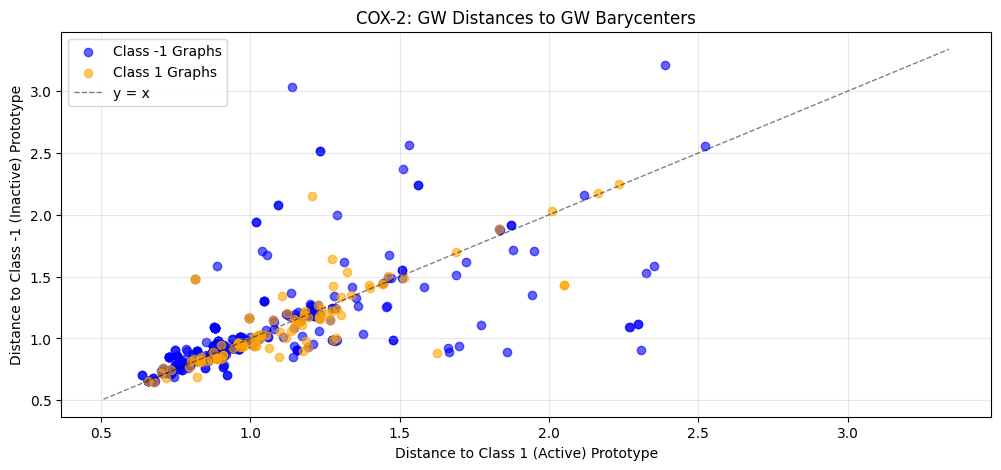

In [24]:
# Plot results
distances = (gw_distances_from_negone_to_negonebary + gw_distances_from_one_to_negonebary + 
            gw_distances_from_negone_to_onebary + gw_distances_from_one_to_onebary)
min_dist = min(distances)
max_dist = max(distances)
margin = (max_dist - min_dist) * 0.05  # Add 5% margin

axis_min = min_dist - margin
axis_max = max_dist + margin

plt.figure(figsize=(12, 5))
plt.scatter(gw_distances_from_negone_to_negonebary, gw_distances_from_negone_to_onebary, 
           alpha=0.6, label='Class -1 Graphs', color='blue')
plt.scatter(gw_distances_from_one_to_negonebary, gw_distances_from_one_to_onebary, 
           alpha=0.6, label='Class 1 Graphs', color='orange')
# Add diagonal line
plt.plot([axis_min, axis_max], [axis_min, axis_max],'k--', alpha=0.5, linewidth=1, label='y = x')
plt.xlabel('Distance to Class 1 (Active) Prototype')
plt.ylabel('Distance to Class -1 (Inactive) Prototype')
plt.title('COX-2: GW Distances to GW Barycenters')
plt.legend()
plt.grid(True, alpha=0.3)

In [25]:
## Repeat the same experiment with fGW distances and fGW barycenters ##
# Compute the fGW barycenter for each category
# Get node attributes for class 1
num_nodes_class1 = 41
num_nodes_class2 = 41
features_class1 = []
class1_indices = [
    j for j in range(len(distance_matrices)) if labels_list[j] == -1
]
for graph_idx in class1_indices:
    graph = graphs_list[graph_idx]
    graph_features = np.array(
        [graph.nodes[n]['attributes'] for n in graph.nodes()])
    features_class1.append(graph_features)

# Create uniform distributions for each graph
ps_class1 = [
    np.ones(len(features)) / len(features)
    for features in features_class1
]
lambdas_class1 = np.ones(len(features_class1)) / len(features_class1)

barycenter_features_class1, barycenter_matrix_class1, log_class1 = ot.gromov.fgw_barycenters(
    N=num_nodes_class1,
    Ys=features_class1,
    Cs=X_class1,
    ps=ps_class1,
    lambdas=lambdas_class1,
    alpha=0.2,
    loss_fun='square_loss',
    random_state=seed,
    log=True)

print("GW barycenter for Class 1 graphs:",
          barycenter_matrix_class1)
print("GW barycenter for Class 1 graphs computed")

# Get node attributes for class 2
features_class2 = []
class2_indices = [
    j for j in range(len(distance_matrices)) if labels_list[j] == 1
]
for graph_idx in class2_indices:
    graph = graphs_list[graph_idx]
    graph_features = np.array(
        [graph.nodes[n]['attributes'] for n in graph.nodes()])
    features_class2.append(graph_features)

# Create uniform distributions for each graph
ps_class2 = [
    np.ones(len(features)) / len(features)
    for features in features_class2
]
lambdas_class2 = np.ones(len(features_class2)) / len(features_class2)

barycenter_features_class2, barycenter_matrix_class2, log_class2 = ot.gromov.fgw_barycenters(
    N=num_nodes_class2,
    Ys=features_class2,
    Cs=X_class2,
    ps=ps_class2,
    lambdas=lambdas_class2,
    alpha=0.2,
    loss_fun='square_loss',
    random_state=seed,
    log=True)
print("GW barycenter for Class 2 graphs:",
          barycenter_matrix_class2)
print("GW barycenter for Class 2 graphs computed")

GW barycenter for Class 1 graphs: [[ 0.27986933 10.44091834  2.37623716 ...  3.86847845  8.36638584
   6.40980692]
 [10.44091834  0.16480853  8.38074524 ...  6.66902567 12.15233958
   5.91016634]
 [ 2.37623716  8.38074524  0.28466419 ...  1.81128994  7.08585255
   4.33829095]
 ...
 [ 3.86847845  6.66902567  1.81128994 ...  0.247423    6.19048421
   2.70111813]
 [ 8.36638584 12.15233958  7.08585255 ...  6.19048421  0.22319348
   8.49596837]
 [ 6.40980692  5.91016634  4.33829095 ...  2.70111813  8.49596837
   0.41663848]]
GW barycenter for Class 1 graphs computed
GW barycenter for Class 2 graphs: [[ 0.37954022  7.046643    2.00332277 ...  1.34317441  9.60847782
   2.10288662]
 [ 7.046643    0.12285261  8.01407088 ...  6.62094543 13.38939279
   5.14500445]
 [ 2.00332277  8.01407088  0.43043149 ...  1.62376321  9.27439243
   3.19832784]
 ...
 [ 1.34317441  6.62094543  1.62376321 ...  0.4560794   8.56173069
   1.79913083]
 [ 9.60847782 13.38939279  9.27439243 ...  8.56173069  0.14908515
   

In [26]:
def compute_fused_gromov_wasserstein_distance(graph_obj, matrix1, matrix2, bary_features):
    for n in graph_obj.nodes():
        m1_features = [graph_obj.nodes[n]['attributes']]

    # Compute metric cost matrix for graph
    M = ot.dist(np.array(m1_features), bary_features)

    fgw, log_fgw = ot.gromov.fused_gromov_wasserstein(
        M,
        matrix1,
        matrix2,
        loss_fun='square_loss',
        alpha=0.5,
        log=True)

    return log_fgw['fgw_dist']

In [27]:
# Distances from each class to each barycenter
fgw_distances_from_negone_to_negonebary = []
fgw_distances_from_one_to_negonebary = []
fgw_distances_from_negone_to_onebary = []
fgw_distances_from_one_to_onebary = []

for j in range(len(distance_matrices)):
    if labels_list[j] == -1:
        
        dist_negone = compute_fused_gromov_wasserstein_distance(graphs_list[j], distance_matrices[j], barycenter_matrix_class1, barycenter_features_class1)
        dist_one = compute_fused_gromov_wasserstein_distance(graphs_list[j], distance_matrices[j], barycenter_matrix_class2, barycenter_features_class2)
        fgw_distances_from_negone_to_negonebary.append(dist_negone)
        fgw_distances_from_negone_to_onebary.append(dist_one) 
    else:
        dist_negone = compute_fused_gromov_wasserstein_distance(graphs_list[j], distance_matrices[j], barycenter_matrix_class1, barycenter_features_class1)
        dist_one = compute_fused_gromov_wasserstein_distance(graphs_list[j], distance_matrices[j], barycenter_matrix_class2, barycenter_features_class2)
        fgw_distances_from_one_to_negonebary.append(dist_negone)
        fgw_distances_from_one_to_onebary.append(dist_one)

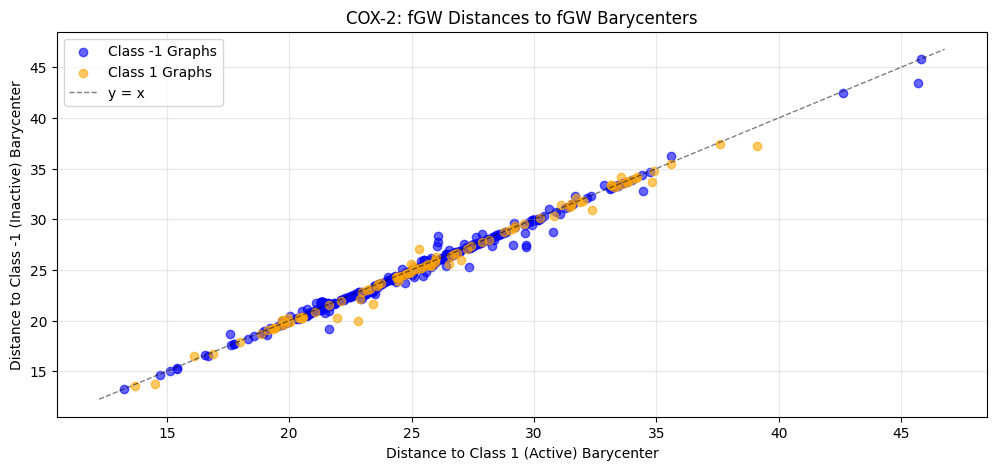

In [28]:
# Plot results
distances_fgw = (fgw_distances_from_negone_to_negonebary + fgw_distances_from_one_to_negonebary + 
            fgw_distances_from_negone_to_onebary + fgw_distances_from_one_to_onebary)
min_dist = min(distances_fgw)
max_dist = max(distances_fgw)
margin = (max_dist - min_dist) * 0.03  # Add 5% margin

axis_min = min_dist - margin
axis_max = max_dist + margin

plt.figure(figsize=(12, 5))
plt.scatter(fgw_distances_from_negone_to_negonebary, fgw_distances_from_negone_to_onebary, 
           alpha=0.6, label='Class -1 Graphs', color='blue')
plt.scatter(fgw_distances_from_one_to_negonebary, fgw_distances_from_one_to_onebary, 
           alpha=0.6, label='Class 1 Graphs', color='orange')
# Add diagonal line
plt.plot([axis_min, axis_max], [axis_min, axis_max],'k--', alpha=0.5, linewidth=1, label='y = x')
plt.xlabel('Distance to Class 1 (Active) Barycenter')
plt.ylabel('Distance to Class -1 (Inactive) Barycenter')
plt.title('COX-2: fGW Distances to fGW Barycenters')
plt.legend()
plt.grid(True, alpha=0.3)